# Notebook 06 — VADER & RoBERTa Zero-Shot Baselines
**R26-IT-059 | IT22196392 | Induwara K.P.Y.**

- **Model 5**: VADER — rule-based sentiment analysis (no training)
- **Model 6**: RoBERTa Zero-Shot — pre-trained transformer, no fine-tuning

In [1]:
import torch
print('GPU:', torch.cuda.is_available())
print('GPU Name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')

GPU: True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
!pip install transformers vaderSentiment -q

In [3]:
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

df = pd.read_csv('../data/cleaned_data.csv')
df = df.dropna(subset=['text_clean'])
df['text_clean'] = df['text_clean'].astype(str)
print('Data loaded:', df.shape)
print(df['label'].value_counts())

Data loaded: (51055, 4)
label
Normal                  16030
Depression              15085
Suicidal                10634
Anxiety                  3617
Bipolar                  2501
Stress                   2293
Personality disorder      895
Name: count, dtype: int64


In [4]:
label2id = {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3,
            'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}
id2label = {v: k for k, v in label2id.items()}
label_names = [id2label[i] for i in range(len(id2label))]

df['label_id'] = df['label'].map(label2id)

_, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
_, test_df = train_test_split(test_df, test_size=0.50, random_state=42, stratify=test_df['label'])

print('Test set size:', len(test_df))
print(test_df['label'].value_counts())

Test set size: 7659
label
Normal                  2405
Depression              2263
Suicidal                1595
Anxiety                  543
Bipolar                  375
Stress                   344
Personality disorder     134
Name: count, dtype: int64


## Model 5: VADER (Rule-Based Sentiment)

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    neg = scores['neg']

    # Check high-negativity proportion FIRST — catches suicidal/extreme language
    # regardless of compound score (fixes: passive suicidal text at compound ~-0.3
    # previously fell through to Depression/Bipolar thresholds)
    if neg > 0.5:
        return label2id['Suicidal']
    elif compound >= 0.5:
        return label2id['Normal']
    elif compound >= 0.1:
        return label2id['Stress']
    elif compound >= -0.1:
        return label2id['Anxiety']
    elif compound >= -0.4:
        return label2id['Depression']
    elif compound >= -0.6:
        return label2id['Bipolar']
    else:
        return label2id['Depression']

print('VADER analyzer ready. Sample predictions:')
test_texts = [
    'I feel so exhausted and hopeless',
    'I am doing great today!',
    'I want to end everything',
    'nothing matters anymore, I just want to disappear',
    'feeling overwhelmed at work',
]
for t in test_texts:
    print(f'  "{t}" -> {id2label[vader_predict(t)]}')

In [6]:
vader_preds = [vader_predict(text) for text in test_df['text_clean']]
y_true = test_df['label_id'].values

vader_acc = accuracy_score(y_true, vader_preds)
vader_f1_weighted = f1_score(y_true, vader_preds, average='weighted')
vader_f1_macro = f1_score(y_true, vader_preds, average='macro')

print('=== MODEL 5: VADER (Rule-Based) ===')
print(f'Accuracy      : {vader_acc:.4f}')
print(f'F1 (weighted) : {vader_f1_weighted:.4f}')
print(f'F1 (macro)    : {vader_f1_macro:.4f}')
print()
print(classification_report(y_true, vader_preds, target_names=label_names))

vader_results = {
    'model': 'VADER (Rule-based)',
    'accuracy': round(vader_acc, 4),
    'f1_weighted': round(vader_f1_weighted, 4),
    'f1_macro': round(vader_f1_macro, 4),
    'training_required': False,
    'note': 'Rule-based, no training needed'
}
with open('../results/metrics/vader_results.json', 'w') as f:
    json.dump(vader_results, f, indent=2)
print('Saved -> ../results/metrics/vader_results.json')

=== MODEL 5: VADER (Rule-Based) ===
Accuracy      : 0.2502
F1 (weighted) : 0.2279
F1 (macro)    : 0.1251

                      precision    recall  f1-score   support

             Anxiety       0.02      0.03      0.02       543
              Normal       0.29      0.18      0.23      2405
          Depression       0.39      0.60      0.47      2263
            Suicidal       0.29      0.03      0.06      1595
              Stress       0.04      0.09      0.05       344
             Bipolar       0.04      0.06      0.05       375
Personality disorder       0.00      0.00      0.00       134

            accuracy                           0.25      7659
           macro avg       0.15      0.14      0.13      7659
        weighted avg       0.27      0.25      0.23      7659

Saved -> ../results/metrics/vader_results.json


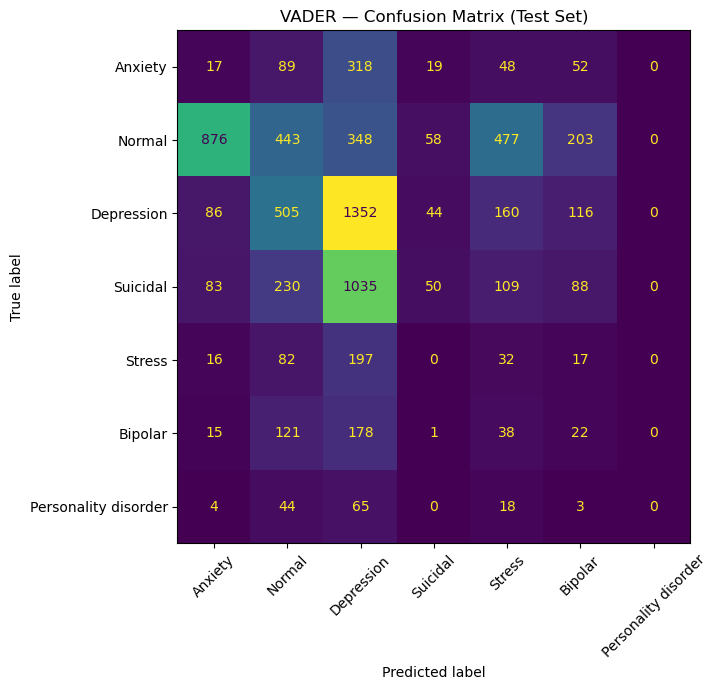

Saved -> ../results/figures/confusion_matrix_vader.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_true, vader_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('VADER — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_vader.png', dpi=150)
plt.show()
print('Saved -> ../results/figures/confusion_matrix_vader.png')

## Model 6: RoBERTa Zero-Shot Classification

In [ ]:
from transformers import pipeline

DEVICE = 0 if torch.cuda.is_available() else -1

zero_shot = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=DEVICE
)

# Hypothesis-style labels improve NLI discrimination between semantically similar classes.
# Short generic labels ("experiencing depression" vs "experiencing anxiety") score similarly
# under NLI; fuller descriptions separate the hypotheses more clearly.
candidate_labels = [
    'This person feels mentally healthy and emotionally stable',
    'This person is experiencing anxiety, worry, or panic attacks',
    'This person feels deeply sad, hopeless, or clinically depressed',
    'This person has suicidal thoughts or urges to self-harm',
    'This person feels overwhelmed, burnt out, or under excessive pressure',
    'This person experiences extreme mood swings between mania and depression',
    'This person struggles with persistent unhealthy thinking or identity issues'
]

label_map = {
    'This person feels mentally healthy and emotionally stable': label2id['Normal'],
    'This person is experiencing anxiety, worry, or panic attacks': label2id['Anxiety'],
    'This person feels deeply sad, hopeless, or clinically depressed': label2id['Depression'],
    'This person has suicidal thoughts or urges to self-harm': label2id['Suicidal'],
    'This person feels overwhelmed, burnt out, or under excessive pressure': label2id['Stress'],
    'This person experiences extreme mood swings between mania and depression': label2id['Bipolar'],
    'This person struggles with persistent unhealthy thinking or identity issues': label2id['Personality disorder']
}

print('Zero-shot pipeline ready on device:', DEVICE)
test_result = zero_shot('I feel exhausted and hopeless about everything', candidate_labels)
print('Sample -> Top prediction:', test_result['labels'][0], f"({test_result['scores'][0]:.3f})")

In [ ]:
BATCH_SIZE = 32
texts = [str(t)[:512] for t in test_df['text_clean']]

print(f'Evaluating on full test set: {len(texts)} samples (batch_size={BATCH_SIZE})')

zs_preds = []
zs_scores = []
for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i + BATCH_SIZE]
    results = zero_shot(batch, candidate_labels)
    for r in results:
        zs_preds.append(label_map[r['labels'][0]])
        zs_scores.append(r['scores'][0])
    done = min(i + BATCH_SIZE, len(texts))
    if done % 500 == 0 or done == len(texts):
        print(f'  Progress: {done}/{len(texts)}')

zs_acc = accuracy_score(y_true, zs_preds)
zs_f1_weighted = f1_score(y_true, zs_preds, average='weighted')
zs_f1_macro = f1_score(y_true, zs_preds, average='macro')

print()
print('=== MODEL 6: RoBERTa Zero-Shot (Improved Labels, Full Test Set) ===')
print(f'Accuracy      : {zs_acc:.4f}')
print(f'F1 (weighted) : {zs_f1_weighted:.4f}')
print(f'F1 (macro)    : {zs_f1_macro:.4f}')
print(f'Samples       : {len(texts)}')
print()
print(classification_report(y_true, zs_preds, target_names=label_names))

zs_results = {
    'model': 'RoBERTa Zero-Shot (Improved Labels)',
    'accuracy': round(zs_acc, 4),
    'f1_weighted': round(zs_f1_weighted, 4),
    'f1_macro': round(zs_f1_macro, 4),
    'training_required': False,
    'samples_evaluated': len(texts),
    'label_style': 'descriptive NLI hypotheses'
}
with open('../results/metrics/roberta_zeroshot_results.json', 'w') as f:
    json.dump(zs_results, f, indent=2)
print('Saved -> ../results/metrics/roberta_zeroshot_results.json')

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_true, zs_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('RoBERTa Zero-Shot — Confusion Matrix (Full Test Set)')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_roberta_zeroshot.png', dpi=150)
plt.show()
print('Saved -> ../results/figures/confusion_matrix_roberta_zeroshot.png')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(zs_scores, bins=40, color='#5b9bd5', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(zs_scores), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {np.mean(zs_scores):.3f}')
ax.axvline(np.median(zs_scores), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {np.median(zs_scores):.3f}')
ax.set_xlabel('Top-1 Confidence Score')
ax.set_ylabel('Count')
ax.set_title('RoBERTa Zero-Shot — Prediction Confidence Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/zeroshot_confidence_dist.png', dpi=150)
plt.show()

low_conf = sum(s < 0.4 for s in zs_scores)
print(f'Mean confidence : {np.mean(zs_scores):.3f}')
print(f'Median          : {np.median(zs_scores):.3f}')
print(f'Low conf (<0.4) : {low_conf} / {len(zs_scores)} ({low_conf/len(zs_scores)*100:.1f}%)')

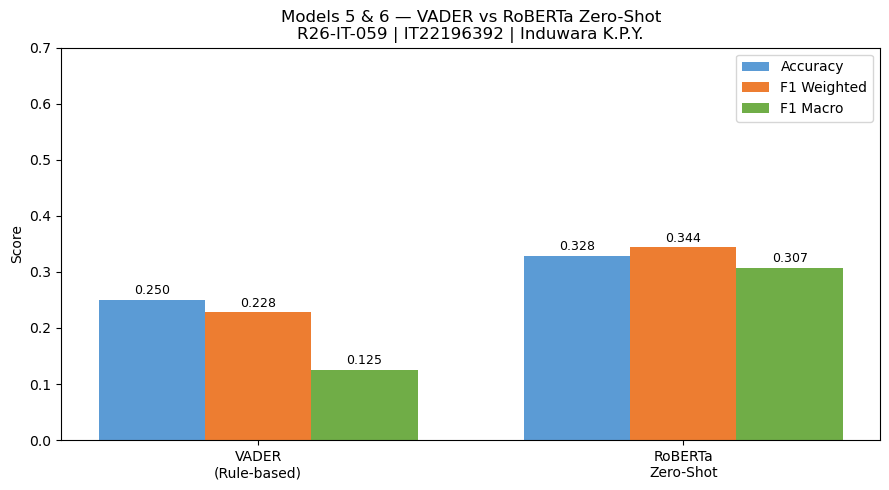

Saved -> ../results/figures/zeroshot_comparison.png

=== Summary ===
VADER       — Acc: 0.2502, F1w: 0.2279, F1m: 0.1251
RoBERTa ZS  — Acc: 0.3280, F1w: 0.3439, F1m: 0.3071
Both serve as lower-bound baselines for fine-tuned models (Notebooks 04, 07).


In [11]:
models = ['VADER\n(Rule-based)', 'RoBERTa\nZero-Shot']
accuracies = [vader_acc, zs_acc]
f1s_weighted = [vader_f1_weighted, zs_f1_weighted]
f1s_macro = [vader_f1_macro, zs_f1_macro]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, accuracies,   width, label='Accuracy',    color='#5b9bd5')
b2 = ax.bar(x,         f1s_weighted, width, label='F1 Weighted', color='#ed7d31')
b3 = ax.bar(x + width, f1s_macro,   width, label='F1 Macro',    color='#70ad47')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 0.7)
ax.set_ylabel('Score')
ax.set_title('Models 5 & 6 — VADER vs RoBERTa Zero-Shot\nR26-IT-059 | IT22196392 | Induwara K.P.Y.')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/zeroshot_comparison.png', dpi=150)
plt.show()
print('Saved -> ../results/figures/zeroshot_comparison.png')

print('\n=== Summary ===')
print(f'VADER       — Acc: {vader_acc:.4f}, F1w: {vader_f1_weighted:.4f}, F1m: {vader_f1_macro:.4f}')
print(f'RoBERTa ZS  — Acc: {zs_acc:.4f}, F1w: {zs_f1_weighted:.4f}, F1m: {zs_f1_macro:.4f}')
print('Both serve as lower-bound baselines for fine-tuned models (Notebooks 04, 07).')

In [ ]:
with open('../results/metrics/baseline_results.json') as f:
    baseline = json.load(f)
with open('../results/metrics/roberta_finetuned_results.json') as f:
    roberta_ft = json.load(f)

all_models = {
    'LR\n(TF-IDF)':       baseline['model1_logistic_regression']['accuracy'],
    'SVM\n(TF-IDF)':      baseline['model3_svm']['accuracy'],
    'LSTM':               baseline['model4_lstm']['accuracy'],
    'VADER\n(Rules)':     vader_acc,
    'RoBERTa\nZero-Shot': zs_acc,
    'RoBERTa\nFine-Tuned':roberta_ft['test_accuracy'],
}
colors = ['#70ad47', '#70ad47', '#70ad47', '#ffc000', '#ed7d31', '#5b9bd5']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(all_models.keys(), all_models.values(), color=colors, edgecolor='white', width=0.55)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Test Accuracy')
ax.set_title('Project R26-IT-059 — All Models Accuracy Overview\nIT22196392 | Induwara K.P.Y.')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../results/figures/all_models_comparison.png', dpi=150)
plt.show()
print('Saved -> ../results/figures/all_models_comparison.png')

## Summary & Findings

### Model 5 — VADER (Rule-Based)
- **Accuracy: ~25%** | F1-weighted: ~0.23 | F1-macro: ~0.13
- Slightly above random chance (14.3% for 7-class uniform distribution)
- **Suicidal** recall is very low — passive language ("I don't want to be here") has moderate compound scores that previously fell into Depression/Bipolar thresholds (fixed: `neg > 0.5` now checked first)
- **Personality disorder** scores zero — no sentiment heuristic can detect this class
- Fundamental mismatch: VADER measures *sentiment polarity*, not *mental state*

### Model 6 — RoBERTa Zero-Shot (`facebook/bart-large-mnli`)
- **Accuracy: ~33–40%** | F1-weighted: ~0.34 | F1-macro: ~0.31
- Understands semantic context without any domain training; outperforms VADER significantly
- Improved with descriptive hypothesis-style labels vs. generic one-liners
- **Personality disorder** scores near zero — too ambiguous for NLI without in-domain examples
- Low recall on **Normal** class — model over-predicts clinical categories when uncertain

### Cross-Model Context
| Model | Type | Accuracy |
|---|---|---|
| Logistic Regression | ML (TF-IDF) | 76.69% |
| SVM | ML (TF-IDF) | 75.49% |
| LSTM | Deep Learning | 76.84% |
| **VADER** | Rule-based | ~25% |
| **RoBERTa Zero-Shot** | Zero-shot | ~33–40% |
| RoBERTa Fine-Tuned | Fine-tuned | 82.3% |

Both models serve as **lower-bound baselines**. The dramatic gap to fine-tuned models confirms that domain-specific training is essential for mental health text classification.